# B04a · Scaling rows, features and classes

Portable notebook: Python + NumPy; no workspace dependency. The packet contains author evidence and complete executable source subset. Replay does not run pretrained TabFlex. Three live learner functions drive the exercises. Figure9 remains INCOMPLETE_SOURCE_PROTOCOL. Online course links may require later publication; figures, code and evidence below are embedded.

In [ ]:
import base64,hashlib,io,json,math,re,tarfile,tempfile,zipfile,copy
from pathlib import Path
import numpy as np
workspace=Path(tempfile.mkdtemp(prefix="b04a-notebook-"))

<p class="eyebrow">Research bridge · B04a · elective</p>

# Scaling rows, features and classes

**Your win:** locate the bottleneck in a tabular predictor, replace a pairwise kernel calculation with sufficient statistics, and defend a comparison that preserves the prediction task.

[B04: TabICL](https://avistian.github.io/relational/lessons/b04-tabicl-scalable-icl.html) compressed each row before dataset attention. Its remaining question was: **can we avoid constructing interactions between every query and every support row?** TabFlex changes that operation. It does not make feature width or class capacity disappear. This matters for the relational mission: flattening a database can multiply columns, while retrieving more related rows increases context. Those are different interventions.

**Route:** 25–35 minutes for the lesson, then the elective's 3–5 hour lab and defense. [Student notebook](https://avistian.github.io/relational/labs/b04a-scaling-rows-features-classes.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/b04a-scaling-rows-features-classes.html) · [Reference](https://avistian.github.io/relational/reference/b04a-scaling-axes.html) · [Reproduction contract](https://avistian.github.io/relational/labs/b04a-reproduction.md).

## 1. Retrieve the shapes before the formula

Close B04 and answer: what are a support row, a query row, and a held-out target? Where does feature compression happen? Why is a frozen model allowed to use support labels but not query labels?

A **support set** supplies examples and their labels. A **query set** supplies examples to predict. We use **S** support rows, **Q** query rows, **F** raw features, **C** classes, **d** coordinates in an attention head and **dv** value coordinates. F is not d: an encoder can map 256 raw features into a 16-dimensional vector, but that encoding has a cost and loses information.

Take S=128, Q=64, F=64, d=16 and dv=2. An explicit query-to-support score matrix contains 64×128=8,192 numbers. The two support summaries below contain 16×2+16=48 numbers. That comparison counts these intermediates only: inputs, outputs, projections and other model layers still exist. It is not a measured memory ratio for TabFlex. [Attention formulation](https://arxiv.org/html/2506.05584v1#S3).

## 2. Change the operator, then reassociate it

Ordinary softmax attention assigns support j a weight proportional to `exp(q · k_j / sqrt(d))`. Linear attention instead chooses a positive feature map φ and uses `φ(q) · φ(k_j)` as its similarity. TabFlex's released ELU+1 map is `φ(x)=x+1` for x≥0 and `exp(x)` for x<0. These similarities are different; linear attention is not an exact rearrangement of softmax.

Once the kernel has been chosen, reassociation **is** exact up to floating-point arithmetic:

```text
A = φ(K)ᵀ V                  # d × dv, weighted value totals
z = sum_j φ(k_j)              # d, support mass
output(q) = φ(q) A / (φ(q) z + ε)
```

A and z are **sufficient statistics for this readout**: after computing them, this operation needs no individual support row. That is narrower than saying they preserve all useful information in the dataset. Two different support sets can share the same summary. [TabFlex §3 and §5](https://arxiv.org/html/2506.05584v1#S5) · [Released operator](https://avistian.github.io/relational/labs/sources/b04a/linear_attention.py).

**Work one query by hand.** Let q=0, k=[0,1], v=[2,8], all scalar. Then φ(q)=1, φ(k)=[1,2], A=18 and z=3. With ε=0, the answer is 6. With the release's ε=10⁻⁶ it is 18/(3+10⁻⁶). Using a plain sum of v would give 5 and discard the kernel weights. The notebook CHECK uses this oracle, signed inputs, support permutations and query batching.

For fixed d and dv, forming A costs work proportional to S·d·dv, then reading it for Q queries costs Q·d·dv. Explicit kernel weights require Q·S·d work before value aggregation. If d grows, the summary also grows: “linear in rows” does not mean “constant in model width.” FlashAttention can avoid storing a full score matrix while still computing pairwise attention; distinguish arithmetic, stored intermediates and hardware memory traffic. [TabFlex Appendix C.1](https://arxiv.org/html/2506.05584v1#A3.SS1).

**Predict:** at S128/Q64/d16/C2, compare8192explicit weights and48summary values. Double F: which term changes?

## 3. Put the statistic inside the actual model

![TabFlex: synthetic pretraining learns encoders and blocks; support features and labels form row embeddings; each attention head builds a value summary and normalizer; queries read the summary; learned blocks and a class head finish prediction. The course kernel is a smaller untrained mechanism.](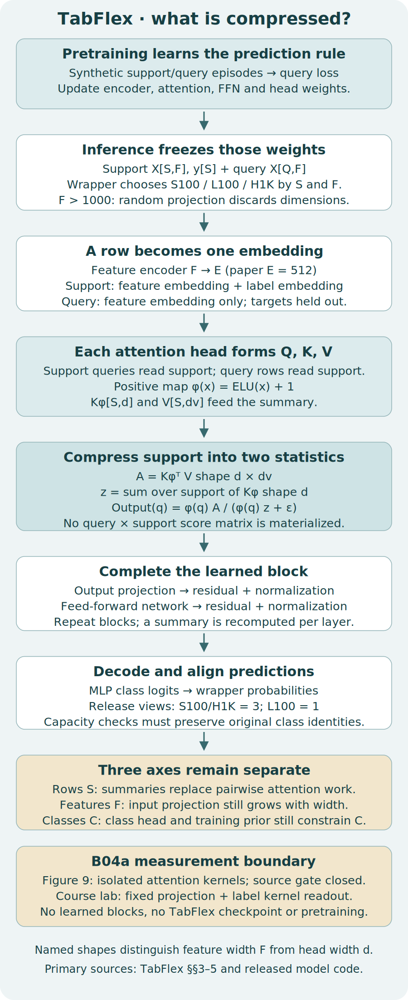)

The released TabFlex model encodes each row, adds a label embedding to support rows, and applies learned attention and feed-forward blocks. Support rows attend to support; query rows read support. Every block recomputes projected keys, values and summaries from its current representation. A final head emits class logits. Pretraining learns those transformations from synthetic episodes; inference uses frozen weights. A single untrained label-averaging kernel is only the mechanism lab below. [Model composition](https://avistian.github.io/relational/labs/sources/b04a/tabflex_model.py) · [Complete executable source archive](https://avistian.github.io/relational/labs/sources/b04a/code.tar.gz).

The pinned wrapper selects L100 for S≥3000 and F≤100; otherwise H1K for F>100 (or its stated high-dimensional condition), and S100 for the remaining cases. Beyond 1000 features it requests random projection. It uses one ensemble configuration for L100 and three for S100/H1K. So a comparison that crosses a routing boundary can change checkpoint, feature reduction and ensemble size together. [Release routing](https://avistian.github.io/relational/labs/sources/b04a/tabflex_wrapper.py).

**Source reading trap:** Figure 9's Listing 1 times the unnormalized core `Q(KᵀV)`. The released model also maps Q/K and divides by a normalizer. Those are related but distinct operations. Our parity test executes the unmodified released operator on random tensors; it does not validate the figure's timings, a checkpoint's quality or the whole transformer.

## 4. Three axes, three different questions

| Axis | Question to ask | What a shortcut can discard |
|---|---|---|
| More rows S | Can every query still use all support examples? | Subsampling or retrieval can omit informative examples. |
| More features F | What reaches the row encoder, at what cost? | Selection/projection can remove directions carrying signal. |
| More classes C | Do output columns still represent the original labels? | Merging labels changes the prediction task. |

**TabPFN-Wide changes the training distribution.** Its continued pretraining uses a prior widened through sparse linear mixing and noise. It adapts to wide, correlated tables while retaining the base architecture's computational constraints. More raw columns need not mean more independent signal. The lab's repeated copies are a simple control, not that published widening generator. Attention maps are not causal feature attribution. [Wide §4 and limitations](https://arxiv.org/html/2510.06162v1#S4).

**BETA changes task adaptation and aggregation.** It uses learned encoders and bagging to adapt TabPFN. That is a useful comparison with an attention-kernel change: learned compression and repeated predictions have their own training, selection and inference costs. We do not run BETA or claim a matched performance comparison here. [BETA primary paper](https://arxiv.org/html/2502.02527v1).

**Class capacity is a semantic boundary.** We executed only the pinned release's preprocessing method with a configured capacity of 10. Inputs containing 2 or 10 classes retained their class counts; 11 classes became 10 effective labels. This result is specific to that method and configuration, not a universal TabFlex limit. The course encoder rejects 11 classes instead. Run `class_values([20,10,20], [20,10], 2)` and explain why column order matters even when labels are nonconsecutive.

**Retrieval:** is an11→10label merge the original task? Explain before checking.

## 5. Run a comparison whose inputs are visible

Our frozen **course experiment** has three seeds, S∈{64,256,1024}, F∈{8,64,256}, two widening rules and two kernels: 108 settings, each with 64 queries. For every seed, the eight latent features determine a noisy binary label. Wider inputs either append independent noise or repeat the latent features. Support prefixes are nested; query IDs stay fixed.

The pipeline is visible: **support-fitted mean/std → fixed random projection to d=16 → softmax or ELU+1 label readout → class probabilities**. Projection weights depend on F, not target values. Every setting uses one view, no optimizer and no hyperparameter selection. Linear outputs are finally normalized over classes; its ε normalizer then cancels from that class distribution. This is explicitly **not pretrained TabFlex inference**.

| Kernel / widening | F | Mean accuracy | Min–max over 3 seeds | Mean log loss |
|---|---:|---:|---:|---:|
| linear / noise | 8 | 69.27% | 51.56–82.81% | 0.655143 |
| linear / noise | 64 | 54.69% | 45.31–64.06% | 0.693164 |
| linear / noise | 256 | 52.08% | 45.31–57.81% | 0.695474 |
| linear / copies | 8 | 69.27% | 51.56–82.81% | 0.655143 |
| linear / copies | 64 | 61.46% | 48.44–68.75% | 0.674925 |
| linear / copies | 256 | 71.35% | 53.12–81.25% | 0.656799 |
| softmax / noise | 8 | 86.98% | 84.38–90.62% | 0.432134 |
| softmax / noise | 64 | 61.98% | 60.94–64.06% | 0.670777 |
| softmax / noise | 256 | 53.65% | 51.56–56.25% | 0.690670 |
| softmax / copies | 8 | 86.98% | 84.38–90.62% | 0.432134 |
| softmax / copies | 64 | 71.35% | 67.19–78.12% | 0.571999 |
| softmax / copies | 256 | 80.21% | 78.12–84.38% | 0.440569 |


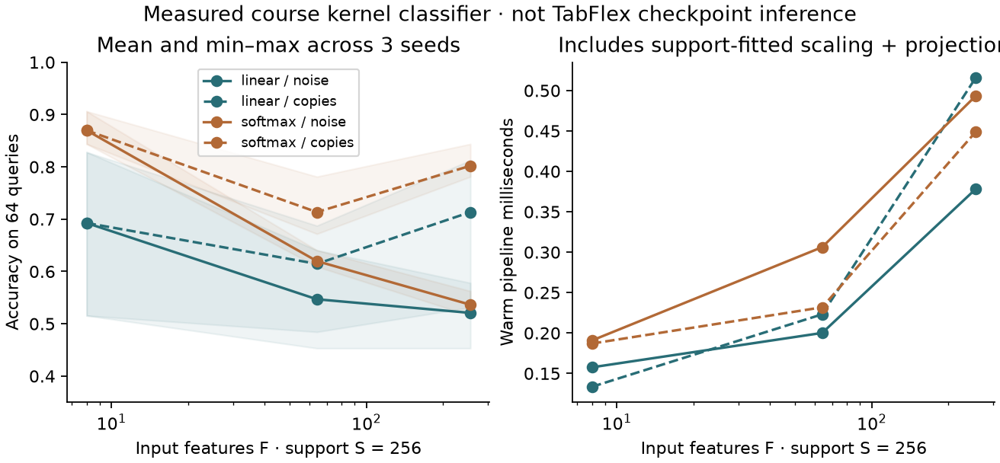

At S=256, adding noise from 8 to 256 features reduced mean accuracy from 69.27% to 52.08% for the linear kernel and from 86.98% to 53.65% for softmax. Three paired seeds support this statement about this generated problem only. Correlated copies introduce no new independent signal, but the projection and similarity geometry change, so their scores need not remain fixed. At F=8, both widening rules are identical; all paired predictions match exactly. This is a useful negative control.

**Inspect:** the complete audit below exposes all108settings. Select a pair before interpreting any score.

**Predict before inspecting:** should a theoretically cheaper attention readout always make this entire small pipeline faster? No. Scaling, projection, allocation and interpreter/library overhead also consume time. Cold is the first pipeline call in a fresh worker; warm is the median of three further complete pipeline calls, including refitting support scaling. Neither flushes the operating system's caches. RSS is peak CPU memory of the whole process, including JSON loading. It is not peak CUDA memory or isolated attention allocation.

The independent audit reconstructs **all 6,912 predictions** using an explicit query×support kernel and independently scores their labels. It rejects missing settings, duplicate identities, reordered queries, changed class columns and other corruptions. Agreement checks arithmetic and recorded identities; it does not prove generalization beyond this experiment. [Frozen inputs, settings and results](https://avistian.github.io/relational/labs/evidence/b04a/reproducer.zip).

A current production TabICLv2 result would answer a different question from a paper-era TabPFN or TabFlex comparison. B04's small checkpoint diagnostic has different inputs and settings, so we do not rank it against this matrix. Fresh current-checkpoint and paper-era model comparisons remain `NOT_RUN` here.

## 6. Full reproduction has an explicit boundary

**B04A-TABFLEX-FIG9-ATTENTION-SCALING — INCOMPLETE_SOURCE_PROTOCOL.** The published target spans three operators, four head widths, four head counts, twelve sequence lengths, batch size 10 and five repetitions: 2,880 planned operator repetitions. Its reported failures cover 120 of those slots for causal FlashLinearAttention. Failures belong in the record; do not silently delete them or replace them with a smaller grid. [Figure 9 protocol](https://arxiv.org/html/2506.05584v1#A3.SS1).

We pinned the repository at `3c36d9c1785844d5e983b0baf0ef4116670aa809`, archived the paper and release, and searched code plus notebook sources. We did not recover an authenticated Figure 9 measurement script, raw per-repeat references, exact input generation/seeds, or a complete hardware/precision/kernel/timing contract. The paper's training hardware does not identify the benchmark hardware. This bounded search does not prove the artifacts exist nowhere.

The packaged `--run` preflight exits before execution. It is a working gate, **not a finished Figure 9 runner**. Unblocking requires recovering those details, implementing the original benchmark dispatch and forecasting the complete grid at verified rates. A changed GPU would require a declared replication protocol and would not reproduce an absolute historical runtime.

Budget: $10 aggregate, $2 reserved, no paid dispatch while the gate is closed. Author cloud/API spend is $0. Whole-paper benchmarks, pretraining, pretrained TabFlex inference, TabPFN-Wide continued training and BETA runs are `NOT_RUN`. These limitations do not disappear when the course lab passes. [Commands and exact evidence boundaries](https://avistian.github.io/relational/labs/b04a-reproduction.md).

## 7. TODO → CHECK → written defense

1. **TODO:** implement associative normalized attention, support-only scaling and an exact class encoder in the student notebook. Predict the hand result first. The implementations must drive the exercises; the notebook leaves these functions blank.
2. **CHECK:** compare your readout with a scalar support-by-support oracle. Permute support rows and batch the queries. Demonstrate rejection of 11 classes under capacity 10. Change query values without refitting the scaler.
3. **APPLY:** select a measured operating point and its paired control. Report what changed, what remained fixed, quality, cold/warm time and peak process RSS. Explain why this is not Figure 9 or checkpoint evidence.
4. **EXIT:** draw the complete TabFlex path, distinguish F from d, name information lost by one scaling shortcut, and give a falsifier for your chosen comparison. State the precise evidence needed to reopen the paper gate.

A passing author package is not your written defense. Status remains **PENDING_WRITTEN_DEFENSE**. Revisit one shape trace tomorrow, an unfamiliar row/feature/class scenario after 7 days, and the comparison contract after 30 days. Ask the teaching agent any follow-up questions or submit your defense for feedback.

**Next:** [B05's planned retrieval-based approach](https://avistian.github.io/relational/plan/year-5-6-bridge.md#b05) chooses which rows enter context. Carry this lesson's information and resource accounting into [B09's operating-point comparison](https://avistian.github.io/relational/plan/year-5-6-bridge.md#b09). Start primary reading with [TabFlex §5 and Appendix C.1](https://arxiv.org/html/2506.05584v1#S5).


In [ ]:
payload=base64.b64decode('...')
assert hashlib.sha256(payload).hexdigest()=='ee8f8d452ece7ebece1db7f075f7d127172dab8b8c724f71c38cba49d9a82545'
with zipfile.ZipFile(io.BytesIO(payload)) as z:z.extractall(workspace)
evidence=workspace/"labs/evidence/b04a"
inputs=json.loads((evidence/"inputs.json").read_text())
protocol=json.loads((evidence/"protocol.json").read_text())

## TODO · linear_readout

Implement ELU+1 and the associative summary/normalizer. Never form query×support weights. Return a Q×dv readout. Use the hand oracle18/(3+eps).

In [ ]:
def linear_readout(q, k, v, eps=1e-6):
    raise NotImplementedError("Implement linear_readout")

## TODO · fit_scale

Return mean and population std fitted on support only. Replace zero std with1. Reject empty/nonfinite inputs.

In [ ]:
def fit_scale(support):
    raise NotImplementedError("Implement fit_scale")

## TODO · class_values

Return one-hot values in the explicitly supplied class order. Reject unknown labels, duplicates or class-count overflow; never silently merge classes.

In [ ]:
def class_values(labels, classes, capacity):
    raise NotImplementedError("Implement class_values")

## CHECK · independent hand and intervention oracles

In [ ]:
def check_functions(linear_readout,fit_scale,class_values):
    # phi(0)=1, phi(log(2))=1+log(2), phi(-log(2))=.5.
    # q=0, k=(0,1), v=(2,8) -> (2+16)/(1+2+eps).
    np.testing.assert_allclose(linear_readout([[0]],[[0],[1]],[[2],[8]]),[[18/(3+1e-6)]],rtol=1e-13)
    np.testing.assert_allclose(linear_readout([[0]],[[-np.log(2)],[0]],[[2],[8]],0),[[6]],rtol=1e-13)
    rng=np.random.default_rng(19);q=rng.normal(size=(5,4));k=rng.normal(size=(7,4));v=rng.normal(size=(7,3))
    # Scalar reference enumerates each support weight, independently of reassociation.
    phi=lambda x: float(np.exp(x)) if x<0 else float(x+1)
    ref=np.zeros((5,3))
    for i in range(5):
        weights=[sum(phi(q[i,d])*phi(k[j,d]) for d in range(4)) for j in range(7)]
        for c in range(3):ref[i,c]=sum(weights[j]*v[j,c] for j in range(7))/(sum(weights)+1e-6)
    out=linear_readout(q,k,v);np.testing.assert_allclose(out,ref,atol=1e-12)
    p=[5,0,3,2,6,1,4];np.testing.assert_allclose(linear_readout(q,k[p],v[p]),out,atol=1e-12)
    np.testing.assert_allclose(np.concatenate([linear_readout(q[:2],k,v),linear_readout(q[2:],k,v)]),out,atol=1e-12)
    mean,scale=fit_scale([[1,7],[3,7]]);np.testing.assert_equal(mean,[2,7]);np.testing.assert_equal(scale,[1,1])
    mean2,scale2=fit_scale([[1,7],[3,7]]);np.testing.assert_equal(mean,mean2)
    vals=class_values([20,10,20],[20,10],2);np.testing.assert_equal(vals,[[1,0],[0,1],[1,0]])
    invalid=[lambda:linear_readout([],[[0]],[[1]]),lambda:linear_readout([[0]],[[float('nan')]],[[1]]),lambda:linear_readout([[0]],[[0]],[[1]],-1),lambda:fit_scale([]),lambda:class_values([0,1,2],[0,1,2],2),lambda:class_values([5],[0,1],2),lambda:class_values([0],[0,0],2)]
    for f in invalid:
        try:f()
        except ValueError:pass
        else:raise AssertionError('Invalid input accepted')
    return {'status':'PASS','checks':'scalar oracle, signed inputs, support permutation, query batching, constant scale, class identity/capacity, invalid inputs'}

In [ ]:
print(check_functions(linear_readout,fit_scale,class_values))

## APPLY · your functions reconstruct one full operating point

Change the seed, support or feature count only after predicting the result. Query labels are read below only after prediction. Holding means fixed, change a query and show no refitting occurs.

In [ ]:
config=next(c for c in protocol["configs"] if c["name"]=="s0-n256-f64-noise-linear")
t=inputs["tables"][str(config["seed"])];n=config["support"];f=config["features"]
x=np.column_stack([np.array(t["latent"]),np.array(t["noise"])])[:,:f]
support=x[t["support_pool"][:n]];query=x[t["query_ids"]]
mean,scale=fit_scale(support);projection=np.random.default_rng(4000+f).normal(size=(f,16))/np.sqrt(f)
k=((support-mean)/scale)@projection;q=((query-mean)/scale)@projection
v=class_values(np.array(t["y"])[t["support_pool"][:n]],protocol["classes"],10)
p=linear_readout(q,k,v);p/=p.sum(1)[:,None]
saved=json.loads((evidence/"runs"/(config["name"]+".json")).read_text())
np.testing.assert_allclose(p,saved["probabilities"],rtol=1e-11,atol=1e-12)
y_query=np.array(t["y"])[t["query_ids"]]
print("Your functions:",sum(p.argmax(1)==y_query),"/64 correct")
changed=query.copy();changed[0]=1000
np.testing.assert_array_equal(mean,fit_scale(support)[0])
print("Frozen query transform:",((changed-mean)/scale).shape)

## PROVIDED · independent explicit-kernel audit

The following verifier does not import the learner functions or worker. It reconstructs every probability using a query×support matrix, scores original labels and rejects corrupted records. Timing values are structurally checked, not rerun.

In [ ]:
def source_gate(folder):
    folder=Path(folder);manifest=json.loads((folder/'manifest.json').read_text())
    for name,meta in manifest['files'].items():
        if hashlib.sha256((folder/name).read_bytes()).hexdigest()!=meta['sha256']:raise ValueError('Source hash mismatch: '+name)
    with tarfile.open(folder/'code.tar.gz') as tar:
        names=[m.name for m in tar.getmembers() if m.isfile()]
        code={n:tar.extractfile(n).read().decode('utf8',errors='replace') for n in names}
    if 'class LinearAttention' not in code['ticl/models/linear_attention.py']:raise ValueError('Missing operator')
    hits={term:[n for n,t in code.items() if re.search(term,t,re.I)] for term in ['flash_attn','fla.ops','do_bench','Figure 9']}
    return {'experiment':'B04A-TABFLEX-FIG9-ATTENTION-SCALING','status':'INCOMPLETE_SOURCE_PROTOCOL','revision':manifest['revision'],'verified_source_files':len(names),'search_hits':hits,'published':{'operators':['FlashAttention-2','causal FlashLinearAttention','noncausal linear attention'],'head_dimensions':[32,64,128,256],'heads':[2,4,8,16],'lengths':[2**k for k in range(4,16)],'batch':10,'repetitions':5,'total_operator_repetitions':2880,'reported_failure_slots':120},'unresolved':['Exact Figure 9 hardware is not tied to a run artifact (training A100 is not sufficient evidence).','Original random-input distribution, seeds and Q/K/V sharing are not authenticated.','Dtype, kernel versions, warmups, synchronization, forward/backward scope and memory reset/aggregation are not authenticated.','Original measurement script and per-repetition numeric references were not recovered in the archived tree.'],'benchmark_runs':0,'full_pretraining':'NOT_RUN','whole_paper_benchmark':'NOT_RUN','historical_identity':'NOT_ESTABLISHED'}

In [ ]:
def audit_records(inputs,protocol,records):
    expected={c['name']:c for c in protocol['configs']}
    if len(records)!=len(expected) or len({r['config']['name'] for r in records})!=len(expected):raise ValueError('Missing or duplicate settings')
    rows=[]
    for record in records:
        c=record['config'];name=c['name']
        if c!=expected.get(name) or record['status']!='COMPLETE':raise ValueError('Wrong configuration')
        t=inputs['tables'][str(c['seed'])];ids=t['support_pool'][:c['support']];queries=t['query_ids']
        if record['inputs_sha256']!=protocol['inputs_sha256'] or record['support_ids']!=ids or record['query_ids']!=queries or set(ids)&set(queries):raise ValueError('Input/row identity mismatch')
        if record['classes']!=protocol['classes']:raise ValueError('Class columns changed')
        x=np.array(t['latent']);f=c['features']
        if c['widening']=='noise':x=np.column_stack([x,np.array(t['noise'])])[:,:f]
        else:x=x[:,[i%8 for i in range(f)]]
        a=x[ids];b=x[queries];mu=np.sum(a,axis=0)/len(a);sd=np.sqrt(np.sum((a-mu)**2,axis=0)/len(a));sd[sd==0]=1
        if not np.allclose(mu,record['mean'],rtol=1e-12,atol=1e-12) or not np.allclose(sd,record['scale'],rtol=1e-12,atol=1e-12):raise ValueError('Preprocessing mismatch')
        w=np.random.default_rng(4000+f).normal(size=(f,16))/math.sqrt(f);k=((a-mu)/sd).dot(w);q=((b-mu)/sd).dot(w)
        # Explicit query×support kernel, independently from the associative worker.
        if c['kernel']=='linear':
            pq=np.where(q<0,np.exp(np.minimum(q,0)),q+1);pk=np.where(k<0,np.exp(np.minimum(k,0)),k+1);weights=pq.dot(pk.T)
        else:
            logits=q.dot(k.T)/4;weights=np.exp(logits-np.max(logits,axis=1)[:,None])
        labels=np.array(t['y'])[ids]
        reconstructed=np.column_stack([weights[:,labels==cl].sum(axis=1) for cl in protocol['classes']]);reconstructed/=reconstructed.sum(axis=1)[:,None]
        p=np.asarray(record['probabilities']);truth=np.array(t['y'])[queries]
        if p.shape!=(len(queries),2) or not np.isfinite(p).all() or (p<0).any() or not np.allclose(p.sum(1),1,atol=1e-12,rtol=0):raise ValueError('Invalid probabilities')
        if not np.allclose(p,reconstructed,rtol=1e-11,atol=1e-12):raise ValueError('Prediction reconstruction mismatch')
        correct=sum(int(protocol['classes'][max(range(2),key=lambda j:p[i,j])]==int(y)) for i,y in enumerate(truth))
        loss=sum(-math.log(max(float(p[i,protocol['classes'].index(int(y))]),1e-15)) for i,y in enumerate(truth))/len(truth)
        timings=[record['cold_pipeline_seconds'],record['materialization_seconds'],record['process_seconds'],*record['warm_pipeline_seconds']]
        if len(record['warm_pipeline_seconds'])!=3 or any(not math.isfinite(x) or x<0 for x in timings) or not math.isfinite(record['peak_process_rss_mib']) or record['peak_process_rss_mib']<=0 or record['warm_max_delta']!=0:raise ValueError('Malformed resource receipt')
        rows.append(dict(**c,correct=correct,total=len(truth),accuracy=correct/len(truth),log_loss=loss,cold_seconds=record['cold_pipeline_seconds'],warm_median_seconds=sorted(record['warm_pipeline_seconds'])[1],peak_rss_mib=record['peak_process_rss_mib']))
    rows.sort(key=lambda x:x['name'])
    # Exact negative control: both widening methods are identical at F=8.
    by={r['config']['name']:r for r in records}
    for c in protocol['configs']:
        if c['features']==8 and c['widening']=='noise':
            other=c['name'].replace('-noise-','-copies-')
            if by[c['name']]['probabilities']!=by[other]['probabilities']:raise ValueError('Identical-input negative control failed')
    return {'status':'COMPLETE','configurations':len(rows),'predictions':sum(r['total'] for r in rows),'rows':rows,'prediction_reconstruction':'Independent explicit kernel, atol1e-12 rtol1e-11','eight_feature_negative_control':'EXACT','scope':'Course fixed random projection/kernel classifier; no pretrained TabFlex weights'}

In [ ]:
def verify(root):
    root=Path(root);e=root/'evidence/b04a';protocol=json.loads((e/'protocol.json').read_text());raw_bytes=(e/'inputs.json').read_bytes()
    for path,digest in json.loads((e/'execution-contract.json').read_text()).items():
        if hashlib.sha256((root/path).read_bytes()).hexdigest()!=digest:raise ValueError('Execution identity changed: '+path)
    if hashlib.sha256(raw_bytes).hexdigest()!=protocol['inputs_sha256']:raise ValueError('Inputs corrupted')
    raw=json.loads(raw_bytes);records=[json.loads((e/'runs'/(c['name']+'.json')).read_text()) for c in protocol['configs']]
    report=audit_records(raw,protocol,records)
    if report!=json.loads((e/'audit.json').read_text()):raise ValueError('Saved audit does not match reconstruction')
    gate=source_gate(root/'sources/b04a')
    if gate!=json.loads((e/'source-gate.json').read_text()):raise ValueError('Source gate mismatch')
    rejected=[]
    for mutation in ['missing','duplicate','query_order','support_overlap','classes','probabilities','means','configuration','timing','inputs_hash']:
        bad=copy.deepcopy(records)
        if mutation=='missing':bad.pop()
        elif mutation=='duplicate':bad[-1]=copy.deepcopy(bad[0])
        elif mutation=='query_order':bad[0]['query_ids'].reverse()
        elif mutation=='support_overlap':bad[0]['support_ids'][0]=1024
        elif mutation=='classes':bad[0]['classes'].reverse()
        elif mutation=='probabilities':bad[0]['probabilities'][0]=[.999,.001]
        elif mutation=='means':bad[0]['mean'][0]+=1
        elif mutation=='configuration':bad[0]['config']['features']=7
        elif mutation=='timing':bad[0]['warm_pipeline_seconds']=[]
        elif mutation=='inputs_hash':bad[0]['inputs_sha256']='bad'
        try:audit_records(raw,protocol,bad)
        except ValueError:rejected.append(mutation)
        else:raise AssertionError('Corruption accepted: '+mutation)
    return {'status':'PASS','configurations':report['configurations'],'predictions':report['predictions'],'rejected_corruptions':rejected,'source_status':gate['status']}

In [ ]:
report=verify(workspace/"labs")
Path("b04a-report.json").write_text(json.dumps(report,indent=2)+"\n")
print(json.dumps(report,indent=2))
print(json.dumps(source_gate(workspace/"labs/sources/b04a"),indent=2))

## EXIT · written defense

Explain F versus d, the kernel change versus reassociation, one information loss, and one matched operating point. State a falsifier and the exact Figure9 blockers. Source parity, saved replay and new training are different evidence. Revisit after1/7/30days and ask the teaching agent for feedback.

In [ ]:
submission={"shape_trace":"","kernel_vs_reassociation":"","information_loss":"","paired_operating_point":"","class_boundary":"","falsifier":"","figure9_blockers":"","status":"PENDING_WRITTEN_DEFENSE"}
Path("b04a-submission.json").write_text(json.dumps(submission,indent=2)+"\n")

## Complete visible course inference worker

This worker produced the saved results in fresh processes; executing the replay above does not rerun it.

```python
"""One fresh process per course setting. Query targets never enter predict()."""
import time
START=time.perf_counter()
import hashlib,json,resource,sys
from pathlib import Path
import numpy as np
from relkit.scaling_b04a import linear_readout,fit_scale,class_values
P=Path(__file__).resolve().parent;E=P/'evidence/b04a'

def predict(support,labels,query,classes,projection,kernel):
    mean,scale=fit_scale(support)
    k=((support-mean)/scale)@projection;q=((query-mean)/scale)@projection
    values=class_values(labels,classes,10)
    if kernel=='linear':
        prob=linear_readout(q,k,values)
        prob=prob/prob.sum(axis=1,keepdims=True)
    elif kernel=='softmax':
        scores=q@k.T/np.sqrt(k.shape[1]);scores-=scores.max(axis=1,keepdims=True)
        weights=np.exp(scores);weights/=weights.sum(axis=1,keepdims=True);prob=weights@values
    else:raise ValueError('Unknown kernel')
    return prob,mean,scale

if __name__=='__main__':
    protocol=json.loads((E/'protocol.json').read_text());name=sys.argv[1];config=next(x for x in protocol['configs'] if x['name']==name)
    out=E/'runs'/(name+'.json');out.parent.mkdir(exist_ok=True)
    if out.exists():raise SystemExit('Immutable result exists')
    raw_bytes=(E/'inputs.json').read_bytes()
    if hashlib.sha256(raw_bytes).hexdigest()!=protocol['inputs_sha256']:raise ValueError('Input identity mismatch')
    raw=json.loads(raw_bytes)['tables'][str(config['seed'])];n=config['support'];f=config['features']
    start=time.perf_counter();latent=np.array(raw['latent']);extra=np.array(raw['noise'])
    table=np.concatenate([latent,extra],axis=1)[:,:f] if config['widening']=='noise' else latent[:,np.arange(f)%8]
    support_ids=raw['support_pool'][:n];query_ids=raw['query_ids'];support=table[support_ids];query=table[query_ids];labels=np.array(raw['y'])[support_ids]
    projection=np.random.default_rng(4000+f).normal(size=(f,16))/np.sqrt(f)
    materialize=time.perf_counter()-start;begin=time.perf_counter()
    prob,mean,scale=predict(support,labels,query,protocol['classes'],projection,config['kernel'])
    cold=time.perf_counter()-begin;warm=[];delta=0
    for _ in range(protocol['warm_repeats']):
        begin=time.perf_counter();repeat,_,_=predict(support,labels,query,protocol['classes'],projection,config['kernel']);warm.append(time.perf_counter()-begin);delta=max(delta,float(np.max(np.abs(repeat-prob))))
    result={'config':config,'inputs_sha256':protocol['inputs_sha256'],'support_ids':support_ids,'query_ids':query_ids,'classes':protocol['classes'],'mean':mean.tolist(),'scale':scale.tolist(),'probabilities':prob.tolist(),'cold_pipeline_seconds':cold,'warm_pipeline_seconds':warm,'materialization_seconds':materialize,'process_seconds':time.perf_counter()-START,'peak_process_rss_mib':resource.getrusage(resource.RUSAGE_SELF).ru_maxrss/1024,'warm_max_delta':delta,'status':'COMPLETE'}
    out.write_text(json.dumps(result,separators=(',',':'))+'\n')

```

## Complete released model modules

Unmodified source from the pinned release; inspection appendix, not notebook globals. The complete114-file executable/config/license archive is in the embedded packet. This is source availability, not pretrained checkpoint execution.

### tabflex_model.py

```python
import torch, wandb
import torch.nn as nn 

from ticl.models.encoders import Linear
from ticl.models.linear_attention import get_linear_attention_layers

from ticl.utils import SeqBN

class TabFlex(nn.Module):
    def __init__(
        self, 
        *, 
        model, 
        n_out, 
        emsize, 
        nhead, 
        nhid_factor, 
        nlayers, 
        n_features, 
        dropout=0.0,  
        y_encoder_layer=None,
        decoder=None, 
        input_normalization=False, 
        init_method=None, 
        pre_norm=False,
        activation='gelu', 
        recompute_attn=False, 
        classification_task=True,
        all_layers_same_init=False, 
        efficient_eval_masking=True, 
        y_encoder=None, 
        tabpfn_zero_weights=False,
        local_nhead=4, 
        norm_output = False,
        feature_map = 'identity',
        linear_attention_cfg=None,
    ):
        super().__init__()
        self.classification_task = classification_task
        self.y_encoder = y_encoder_layer
        nhid = emsize * nhid_factor
        self.model = model
        
        self.linear_attention = get_linear_attention_layers(
            d_model = emsize,
            n_layer = nlayers,
            d_intermediate = nhid,
            model = model,
            nheads = nhead,
            linear_attention_cfg = linear_attention_cfg,
            norm_output = norm_output,
            feature_map = feature_map,
        )
        backbone_size = sum(p.numel() for p in self.linear_attention.parameters())
        if wandb.run: wandb.log({"backbone_size": backbone_size})
        print("Number of parameters in backbone: ", backbone_size)

        self.emsize = emsize
        self.encoder = Linear(n_features, emsize, replace_nan_by_zero=True)
        self.decoder = decoder(emsize, nhid, n_out) if decoder is not None else nn.Sequential(nn.Linear(emsize, nhid), nn.GELU(), nn.Linear(nhid, n_out))
        self.input_ln = SeqBN(emsize) if input_normalization else None
        self.init_method = init_method
        self.efficient_eval_masking = efficient_eval_masking
        self.tabpfn_zero_weights = tabpfn_zero_weights
        self.n_out = n_out
        self.nhid = nhid

    def forward(self, src, src_mask=None, single_eval_pos=None):
        assert isinstance(src, tuple), 'inputs (src) have to be given as (x,y) or (style,x,y) tuple'

        if len(src) == 3:  # style is given
            style_src, x_src, y_src = src
        else:
            x_src, y_src = src
        
        x_src = self.encoder(x_src) # transform n_features to emsize
        # transform y as one-hot encoding into emsize
        y_src = self.y_encoder(y_src.unsqueeze(-1) if len(y_src.shape) < len(x_src.shape) else y_src)

        assert src_mask is None
        assert self.efficient_eval_masking
        
        train_x = x_src[:single_eval_pos] + y_src[:single_eval_pos]
        src = torch.cat([train_x, x_src[single_eval_pos:]], 0) # concatenate the training sequence and the test point
        # we have many testing point...

        if self.input_ln is not None:
            src = self.input_ln(src)
            
        # output = self.linear_attention(src, src_mask)
        if self.model in ['linear_attention']:
            src = src.permute(1, 0, 2) # (seq_len, batch_size, emsize) -> (batch_size, seq_len, emsize)
            # the linear attention layers is written for batch_first = True
            output = self.linear_attention(src, single_eval_pos)
            output = output.permute(1, 0, 2)
        else:
            raise NotImplementedError(f"Model {self.model} is not implemented yet.")
        
        output = self.decoder(output) 
        return output[single_eval_pos:]
```

### linear_attention.py

```python
import torch
from torch.nn import Module, Linear, LayerNorm, Dropout
import torch.nn.functional as F
from torch import nn
import math
from ticl.models.layer import TransformerEncoderSimple


class AttentionLayer(Module):
    """Implement the attention layer. Namely project the inputs to multi-head
    queries, keys and values, call the attention implementation and then
    reproject the output.

    It can be thought of as a decorator (see decorator design patter) of an
    attention layer.

    Arguments
    ---------
        attention: Specific inner attention implementation that just computes a
                   weighted average of values given a similarity of queries and
                   keys.
        d_model: The input feature dimensionality for the queries source
        n_heads: The number of heads for the multi head attention
        d_keys: The dimensionality of the keys/queries
                (default: d_model/n_heads)
        d_values: The dimensionality of the values (default: d_model/n_heads)
        d_model_keys: The input feature dimensionality for keys source
        event_dispatcher: str or EventDispatcher instance to be used by this
                          module for dispatching events (default: the default
                          global dispatcher)
    """
    def __init__(self, attention, d_model, n_heads, d_keys=None,
                 d_values=None, d_model_keys=None, event_dispatcher=""):
        super(AttentionLayer, self).__init__()

        # Fill d_keys and d_values
        d_keys = d_keys or (d_model//n_heads)
        d_values = d_values or (d_model//n_heads)
        d_model_keys = d_model_keys or d_model

        self.inner_attention = attention
        self.query_projection = Linear(d_model, d_keys * n_heads)
        self.key_projection = Linear(d_model_keys, d_keys * n_heads)
        self.value_projection = Linear(d_model_keys, d_values * n_heads)
        self.out_projection = Linear(d_values * n_heads, d_model)
        self.n_heads = n_heads

    def forward(self, queries, keys, values, attn_mask, query_lengths,
                key_lengths):
        """Apply attention to the passed in queries/keys/values after
        projecting them to multiple heads.

        In the argument description we make use of the following sizes

            - N: the batch size
            - L: The maximum length of the queries
            - S: The maximum length of the keys (the actual length per sequence
              is given by the length mask)
            - D: The input feature dimensionality passed in the constructor as
              'd_model'

        Arguments
        ---------
            queries: (N, L, D) The tensor containing the queries
            keys: (N, S, D) The tensor containing the keys
            values: (N, S, D) The tensor containing the values
            attn_mask: An implementation of BaseMask that encodes where each
                       query can attend to
            query_lengths: An implementation of  BaseMask that encodes how
                           many queries each sequence in the batch consists of
            key_lengths: An implementation of BaseMask that encodes how
                         many queries each sequence in the batch consists of

        Returns
        -------
            The new value for each query as a tensor of shape (N, L, D).
        """
        
        # Extract the dimensions into local variables
        N, L, _ = queries.shape
        _, S, _ = keys.shape
        H = self.n_heads

        # Project the queries/keys/values
        queries = self.query_projection(queries).view(N, L, H, -1)
        keys = self.key_projection(keys).view(N, S, H, -1)
        values = self.value_projection(values).view(N, S, H, -1)


        # Compute the attention
        new_values = self.inner_attention(
            queries,
            keys,
            values,
            attn_mask,
            query_lengths,
            key_lengths
        ).view(N, L, -1)
        

        # Project the output and return
        return self.out_projection(new_values)




class FeatureMap(Module):
    """Define the FeatureMap interface."""
    def __init__(self, query_dims):
        super().__init__()
        self.query_dims = query_dims

    def new_feature_map(self, device):
        """Create a new instance of this feature map. In particular, if it is a
        random feature map sample new parameters."""
        raise NotImplementedError()

    def forward_queries(self, x):
        """Encode the queries `x` using this feature map."""
        return self(x)

    def forward_keys(self, x):
        """Encode the keys `x` using this feature map."""
        return self(x)

    def forward(self, x):
        """Encode x using this feature map. For symmetric feature maps it
        suffices to define this function, but for asymmetric feature maps one
        needs to define the `forward_queries` and `forward_keys` functions."""
        raise NotImplementedError()

    @classmethod
    def factory(cls, *args, **kwargs):
        """Return a function that when called with the query dimensions returns
        an instance of this feature map.

        It is inherited by the subclasses so it is available in all feature
        maps.
        """
        def inner(query_dims):
            return cls(query_dims, *args, **kwargs)
        return inner


class ActivationFunctionFeatureMap(FeatureMap):
    """Define a feature map that is simply an element-wise activation
    function."""
    def __init__(self, query_dims, activation_function):
        super().__init__(query_dims)
        self.activation_function = activation_function

    def new_feature_map(self, device):
        return

    def forward(self, x):
        return self.activation_function(x)


elu_feature_map = ActivationFunctionFeatureMap.factory(
    lambda x: torch.nn.functional.elu(x) + 1
)

class HedgehogFeatureMap(FeatureMap):
    def __init__(self, query_dims):
        super().__init__(query_dims)
        self.head_dim = query_dims
        self.layer = nn.Linear(self.head_dim, self.head_dim)
        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.layer.weight, mean=0.0, std=1 / math.sqrt(self.head_dim))
        nn.init.zeros_(self.layer.bias)

    def new_feature_map(self, device):
        self.to(device)

    def forward(self, x):
        x_lin = self.layer(x)
        x_softmax = F.softmax(x_lin, dim=-1)
        x_neg = F.softmax(-x_lin, dim=-1)
        x_cat = torch.cat([x_softmax, x_neg], dim=-1)
        return x_cat

hedgehog_feature_map = HedgehogFeatureMap.factory()

identity_feature_map = ActivationFunctionFeatureMap.factory(
    lambda x: x
)

class LinearAttention(Module):
    """Implement unmasked attention using dot product of feature maps in
    O(N D^2) complexity.

    Given the queries, keys and values as Q, K, V instead of computing

        V' = softmax(Q.mm(K.t()), dim=-1).mm(V),

    we make use of a feature map function Φ(.) and perform the following
    computation

        V' = normalize(Φ(Q).mm(Φ(K).t())).mm(V).

    The above can be computed in O(N D^2) complexity where D is the
    dimensionality of Q, K and V and N is the sequence length. Depending on the
    feature map, however, the complexity of the attention might be limited.

    Arguments
    ---------
        feature_map: callable, a callable that applies the feature map to the
                     last dimension of a tensor (default: elu(x)+1)
        eps: float, a small number to ensure the numerical stability of the
             denominator (default: 1e-6)
        event_dispatcher: str or EventDispatcher instance to be used by this
                          module for dispatching events (default: the default
                          global dispatcher)
    """
    def __init__(self, query_dimensions, feature_map=None, eps=1e-6):
        super(LinearAttention, self).__init__()
        self.feature_map = (
            feature_map(query_dimensions) if feature_map else
            elu_feature_map(query_dimensions)
        )
        self.eps = eps

    def forward(self, queries, keys, values, attn_mask, query_lengths,
                key_lengths):
        # Apply the feature map to the queries and keys
        
        self.feature_map.new_feature_map(queries.device)
        Q = self.feature_map.forward_queries(queries)
        K = self.feature_map.forward_keys(keys)
        

        # Apply the key padding mask and make sure that the attn_mask is
        # all_ones
        if attn_mask is not None:
            if not attn_mask.all_ones:
                raise RuntimeError(("LinearAttention does not support arbitrary "
                                    "attention masks"))
        if key_lengths is not None:
            K = K * key_lengths.float_matrix[:, :, None, None]

        # Compute the KV matrix, namely the dot product of keys and values so
        # that we never explicitly compute the attention matrix and thus
        # decrease the complexity
        KV = torch.einsum("nshd,nshm->nhmd", K, values)

        # Compute the normalizer
        Z = 1/(torch.einsum("nlhd,nhd->nlh", Q, K.sum(dim=1))+self.eps)

        # Finally compute and return the new values
        V = torch.einsum("nlhd,nhmd,nlh->nlhm", Q, KV, Z)

        return V.contiguous()
    

class LinearAttentionTransformerEncoderLayer(Module):
    """Self attention and feed forward network with skip connections.

    This transformer encoder layer implements the same encoder layer as
    PyTorch but is a bit more open for extension by receiving the attention
    implementation as a constructor argument.

    Arguments
    ---------
        attention: The attention implementation to use given as a nn.Module
        d_model: The input feature dimensionality
        d_ff: The dimensionality of the intermediate features after the
              attention (default: d_model*4)
        dropout: The dropout rate to apply to the intermediate features
                 (default: 0.1)
        activation: {'relu', 'gelu'} Which activation to use for the feed
                    forward part of the layer (default: relu)
        event_dispatcher: str or EventDispatcher instance to be used by this
                          module for dispatching events (default: the default
                          global dispatcher)
    """
    def __init__(self, attention, d_model, d_ff=None, dropout=0.1,
                 activation="relu", event_dispatcher=""):
        super(LinearAttentionTransformerEncoderLayer, self).__init__()
        d_ff = d_ff or 4*d_model
        self.attention = attention
        self.linear1 = Linear(d_model, d_ff)
        self.linear2 = Linear(d_ff, d_model)
        self.norm1 = LayerNorm(d_model)
        self.norm2 = LayerNorm(d_model)
        self.dropout = Dropout(dropout)
        self.activation = getattr(F, activation)

    def forward(self, x, src_mask=None):
        """Apply the transformer encoder to the input x.

        Arguments
        ---------
            x: The input features of shape (N, L, E) where N is the batch size,
               L is the sequence length (padded) and E is d_model passed in the
               constructor.
            src_mask: None or int
                Split the input into two parts. The first part is the training
                samples and the second part is the testing samples.
        """

        if isinstance(src_mask, int):
            # tabpfn
            single_eval_position = src_mask
            train_samples = x[:,:single_eval_position,:]
            test_samples = x[:,single_eval_position:,:]

            src_mask = None

            # Run self attention and add it to the input
            # the training samples are only attend to themselves
            attn_left = self.attention(
                train_samples, 
                train_samples, 
                train_samples, 
                attn_mask=None, 
                query_lengths=None,
                key_lengths=None,
            )

            # the testing samples attend to training samples
            attn_right = self.attention(
                test_samples,
                train_samples,
                train_samples,
                attn_mask=None, 
                query_lengths=None,
                key_lengths=None,
            )

            attn_output = torch.cat([attn_left, attn_right], dim=1)
        else:
            raise ValueError("Not implemented")
            # mothernet
            # attn_mask = FullMask(num_samples, device=x.device)
            # length_mask = length_mask or \
            # LengthMask(x.new_full((batch_size,), num_samples, dtype=torch.int64))
            # attn_output = self.attention(
            #     x, x, x,
            #     attn_mask=src_mask,
            #     query_lengths=length_mask,
            #     key_lengths=length_mask
            # )

        x = x + self.dropout(attn_output)

        # Run the fully connected part of the layer
        y = x = self.norm1(x)
        y = self.dropout(self.activation(self.linear1(y)))
        y = self.dropout(self.linear2(y))

        output = self.norm2(x+y)

        return output



def get_linear_attention_layers(
    d_model: int,
    n_layer: int,
    d_intermediate: int,
    model = 'linear_attention',
    linear_attention_cfg=None,
    attn_layer_idx=None,
    attn_cfg=None,
    norm_epsilon: float = 1e-5,
    rms_norm: bool = False,
    initializer_cfg=None,
    fused_add_norm=False,
    residual_in_fp32=False,
    device=None,
    dtype=None,
    nheads = 2,
    dropout = 0.0,
    activation = 'gelu',
    pre_norm = False,
    recompute_attn = False,
    all_layers_same_init = False,
    norm_output = False,
    feature_map = 'identity',
):
    if dtype is None:
        dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    if model == 'linear_attention':

        if d_model % nheads != 0:
            raise ValueError(f"nheads {nheads} must divide d_model {d_model}!")
            
        if feature_map == "hedgehog":
            from ticl.models.linear_attention import hedgehog_feature_map
            feature_map_func = hedgehog_feature_map
        
        elif feature_map == "hedgehog_shared":
            from ticl.models.linear_attention import hedgehog_feature_map
            shared_feature_map = hedgehog_feature_map(d_model // nheads)
            feature_map_func = lambda x: shared_feature_map

        elif feature_map in ["identity", "elu"]:
            from ticl.models.linear_attention import elu_feature_map
            feature_map_func = elu_feature_map

        elif feature_map == "identity_for_real":
            from ticl.models.linear_attention import identity_feature_map
            feature_map_func = identity_feature_map


        def attention_layer_creator():
            return AttentionLayer(
                attention=LinearAttention(query_dimensions=d_model // nheads, feature_map=feature_map_func),
                d_model=d_model,
                n_heads=nheads,
                d_keys=d_model // nheads,
                d_values=d_model // nheads)
        
        def encoder_layer_creator():
            return LinearAttentionTransformerEncoderLayer(
                attention=attention_layer_creator(),
                d_model=d_model,
                d_ff=d_intermediate,
                dropout=dropout,
                # activation=activation
                )
        # TODO is norm good here?
        linear_model = TransformerEncoderSimple(encoder_layer_creator=encoder_layer_creator, num_layers=n_layer, norm=LayerNorm(d_model))



        return linear_model
    
    else:
        raise ValueError(f"Unknown model {model}")

```

### tabflex_wrapper.py

```python

from ticl.prediction.tabpfn import TabPFNClassifier
import numpy as np
import pdb
import torch
from ticl.utils import fetch_model


class TabFlex:
    def __init__(
        self,
    ):
        torch.set_num_threads(1)
        fetch_model('ssm_tabpfn_b4_maxnumclasses100_modellinear_attention_numfeatures1000_n1024_validdatanew_warm_08_23_2024_19_25_40_epoch_3140.cpkt')
        fetch_model('ssm_tabpfn_b4_largedatasetTrue_modellinear_attention_nsamples50000_08_01_2024_22_05_50_epoch_110.cpkt')
        fetch_model('ssm_tabpfn_modellinear_attention_08_28_2024_19_00_44_epoch_3110.cpkt')


        self.tabflexh1k = TabPFNClassifier(
            device='cuda', 
            model_string = f'ssm_tabpfn_b4_maxnumclasses100_modellinear_attention_numfeatures1000_n1024_validdatanew_warm_08_23_2024_19_25_40',
            N_ensemble_configurations=3,
            epoch = '3140',
        )

        self.tabflexl100 = TabPFNClassifier(
            device='cuda', 
            model_string = f'ssm_tabpfn_b4_largedatasetTrue_modellinear_attention_nsamples50000_08_01_2024_22_05_50',
            N_ensemble_configurations=1,
            epoch = '110', 
        )

        self.tabflexs100 = TabPFNClassifier(
            device='cuda', 
            model_string = f'ssm_tabpfn_modellinear_attention_08_28_2024_19_00_44',
            N_ensemble_configurations=3,
            epoch = '3110',
        )

    def fit(self, X, y):
        N, D = X.shape

        if N >= 3000 and D <= 100:
            self.model = self.tabflexl100
        elif D > 100 or (D/N >= 0.2 and N >= 3000):
            if D <= 1000:
                self.model = self.tabflexh1k
            else:
                self.model = self.tabflexh1k
                self.model.dimension_reduction = 'random_proj'
                self.model.fit(X, y, overwrite_warning=True)
                return self
        else:
            self.model = self.tabflexs100

        self.model.fit(X, y, overwrite_warning=True)

        return self

    def predict(self, X):
        y = self.model.predict(X)
        return y

```

### tabpfn_wrapper.py

```python
import os, pdb
import pathlib
import random
from pathlib import Path
import itertools
from sklearn.decomposition import PCA

import numpy as np
import torch
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import LabelEncoder, PowerTransformer, QuantileTransformer, RobustScaler
from sklearn.utils import column_or_1d
from sklearn.utils.multiclass import check_classification_targets
from sklearn.utils.validation import check_array, check_is_fitted, check_X_y
from torch.utils.checkpoint import checkpoint

from ticl.model_builder import load_model
from ticl.utils import NOP, normalize_by_used_features_f, normalize_data, remove_outliers
import pandas as pd


def _get_file(e, base_path, add_name, eval_addition):
    """
    Returns the different paths of model_file, model_path and results_file
    """
    model_file = f'models_diff/{add_name}_epoch_{e}.cpkt'
    model_path = os.path.join(base_path, model_file)
    results_file = os.path.join(base_path,
                                f'models_diff/prior_diff_real_results_{add_name}_n_0_epoch_{e}_{eval_addition}.pkl')
    return model_path, results_file


def _check_file(e, base_path, add_name, eval_addition, verbose):
    model_path, results_file = _get_file(e, base_path, add_name, eval_addition)
    if not Path(model_path).is_file():
        if add_name == "download":
            print('We have to download the TabPFN, as there is no checkpoint at ', model_path)
            print('It has about 100MB, so this might take a moment.')
            import requests
            url = 'https://amuellermothernet.blob.core.windows.net/models/download_epoch_100.cpkt'
            r = requests.get(url, allow_redirects=True)
            os.makedirs(os.path.dirname(model_path), exist_ok=True)
            with open(model_path, 'wb') as f:
                f.write(r.content)
        else:
            model_path = None
    else:
        if verbose:
            print(f"loading model from file {model_path}")
    return model_path, results_file


def load_model_workflow(e, add_name, base_path, device='cpu', eval_addition='', verbose=0):
    """
    Workflow for loading a model and setting appropriate parameters for diffable hparam tuning.
    """
    model_path = None
    if e == -1:
        for e_ in range(100, -1, -1):
            model_path_, results_file_ = _check_file(e_, base_path, add_name, eval_addition, verbose)
            if model_path_ is not None:
                e = e_
                model_path, results_file = model_path_, results_file_
                break
    else:
        model_path, results_file = _check_file(e, base_path, add_name, eval_addition, verbose)

    if model_path is None:
        model_path, results_file = _get_file(e, base_path, add_name, eval_addition)
        raise Exception('No checkpoint found at '+str(model_path))
    model, c = load_model(model_path, device, verbose=False)

    return model, c, results_file


class TabPFNClassifier(BaseEstimator, ClassifierMixin):

    models_in_memory = {}

    def __init__(
        self, 
        device='cpu', 
        base_path=pathlib.Path(__file__).parent.parent.resolve(), 
        model_string='download',
        N_ensemble_configurations=3, 
        no_preprocess_mode=False, 
        multiclass_decoder='permutation',
        feature_shift_decoder=True, 
        seed=0, 
        no_grad=True, 
        batch_size_inference=32,
        verbose=False, 
        scale=True, 
        epoch=-1, 
        model=None, 
        config=None,
        max_num_train_samples = np.inf,
    ):
        """
        Initializes the classifier and loads the model.
        Depending on the arguments, the model is either loaded from memory, from a file, or downloaded from the
        repository if no model is found.

        Can also be used to compute gradients with respect to the inputs X_train and X_test. Therefore no_grad has to be
        set to False and no_preprocessing_mode must be True. Furthermore, X_train and X_test need to be given as
        torch.Tensors and their requires_grad parameter must be set to True.


        :param device: If the model should run on cuda or cpu.
        :param base_path: Base path of the directory, from which the folders like models_diff can be accessed.
        :param model_string: Name of the model. Used first to check if the model is already in memory, and if not,
               tries to load a model with that name from the models_diff directory. It looks for files named as
               follows: "prior_diff_real_checkpoint" + model_string + "_n_0_epoch_e.cpkt", where e can be a number
               between 100 and 0, and is checked in a descending order.
        :param N_ensemble_configurations: The number of ensemble configurations used for the prediction. Thereby the
               accuracy, but also the running time, increases with this number.
        :param no_preprocess_mode: Specifies whether preprocessing is to be performed.
        :param multiclass_decoder: If set to permutation, randomly shifts the classes for each ensemble configuration.
        :param feature_shift_decoder: If set to true shifts the features for each ensemble configuration according to a
               random permutation.
        :param seed: Seed that is used for the prediction. Allows for a deterministic behavior of the predictions.
        :param batch_size_inference: This parameter is a trade-off between performance and memory consumption.
               The computation done with different values for batch_size_inference is the same,
               but it is split into smaller/larger batches.
        :param no_grad: If set to false, allows for the computation of gradients with respect to X_train and X_test.
               For this to correctly function no_preprocessing_mode must be set to true.
        """
        if model is not None and model_string != "download":
            raise ValueError("Only one of model_string or model must be provided")
        if model is not None and config is None:
            raise ValueError("config must be provided if model is provided")
        self.verbose = verbose
        self.device = device
        self.N_ensemble_configurations = N_ensemble_configurations
        self.base__path = base_path
        self.base_path = base_path
        self.model_string = model_string
        self.no_preprocess_mode = no_preprocess_mode
        self.feature_shift_decoder = feature_shift_decoder
        self.multiclass_decoder = multiclass_decoder
        self.seed = seed
        self.no_grad = no_grad
        self.epoch = epoch
        self.temperature = None
        self.scale = scale
        self.model = model
        self.config = config
        self.max_num_train_samples = max_num_train_samples

        assert self.no_preprocess_mode if not self.no_grad else True, \
            "If no_grad is false, no_preprocess_mode must be true, because otherwise no gradient can be computed."

        self.batch_size_inference = batch_size_inference

    def remove_models_from_memory(self):
        self.models_in_memory = {}

    def _validate_targets(self, y):
        y_ = column_or_1d(y, warn=True)
        check_classification_targets(y)
        cls, y = np.unique(y_, return_inverse=True)
        if len(cls) < 2:
            raise ValueError(
                "The number of classes has to be greater than one; got %d class"
                % len(cls)
            )

        self.classes_ = cls
        return np.asarray(y, dtype=np.float64, order="C")
    
    def preprocess(self, X, y, overwrite_warning = False, dimension_reduction='random'):
        self.classes_mode = 'full'
        self.dimension_reduction = dimension_reduction
        
        if X.shape[1] > self.max_num_features:
            Warning("The number of features for this classifier is restricted to ", self.max_num_features)

            if self.dimension_reduction == 'random':
                print('Only randomly take ', self.max_num_features, ' features.')
                self.feature_selected = np.random.choice(X.shape[1], self.max_num_features, replace=False)
                X = X[:, self.feature_selected]

            elif self.dimension_reduction == 'random_proj':
                print('Random projection to ', self.max_num_features, ' features.')
                self.random_proj = torch.nn.Linear(X.shape[1], self.max_num_features, bias=False, device=self.device)
                with torch.no_grad():
                    X = self.random_proj(torch.tensor(X, device=self.device)).cpu().numpy()
            
        if len(np.unique(y)) > self.max_num_classes:
            Warning("The number of classes for this classifier is restricted to ", self.max_num_classes)
            print('Only take the first ', self.max_num_classes-1, ' classes, and set others as the last class.')
            # fine the first max_num_class-1 classes that has most samples
            classes, count = np.unique(y, return_counts=True)
            classes = classes[np.argsort(count)[::-1]]
            self.class_sort = classes
            y = np.where(np.isin(y, classes[:self.max_num_classes-1]), y, y-1000)
            # change the labels to 0, 1, 2, ...
            self.label_encoder2 = LabelEncoder()
            self.label_encoder2.fit(y[y>=0])
            y[y>=0] = self.label_encoder2.transform(y[y>=0])
            self.label_encoder3 = LabelEncoder()
            self.label_encoder3.fit(y[y<0])
            # y[y<0] = self.label_encoder3.transform(y[y<0]) + self.max_num_classes - 1
            y[y<0] = self.max_num_classes - 1
            self.classes_mode = 'croped'
            
        if X.shape[0] > self.max_num_train_samples and not overwrite_warning:
            Warning("⚠️ WARNING: TabPFN is not made for datasets with a trainingsize > 1024. Prediction might take a while, be less reliable."
                             "We advise not to run datasets > 10k samples, which might lead to your machine crashing "
                             "(due to quadratic memory scaling of TabPFN)."
                             "Please confirm you want to run by passing overwrite_warning=True to the fit function.")
            selected_samples = np.random.choice(X.shape[0], self.max_num_train_samples, replace=False)
            X = X[selected_samples]
            y = y[selected_samples]

        self.X_ = X
        self.y_ = y
        # Return the classifier
        return self

    def fit(self, X, y, overwrite_warning=False):

        model_key = self.model_string+'|'+str(self.device) + '|' + str(self.epoch)
        if model_key in self.models_in_memory:
            if self.verbose:
                print(f"using model {model_key}")
            model, c, results_file = self.models_in_memory[model_key]
        else:
            if self.model is not None:
                model, c, results_file = self.model, self.config, None
            else:
                model, c, results_file = load_model_workflow(
                    self.epoch, 
                    add_name=self.model_string, 
                    base_path=self.base_path, 
                    device=self.device,
                    eval_addition=''
                )
            self.models_in_memory[model_key] = (model, c, results_file)
            # if len(self.models_in_memory) == 2:
            #    print('Multiple models in memory. This might lead to memory issues. Consider calling remove_models_from_memory()')
        if c.get("model_type", "tabpfn") not in ["tabpfn", "batabpfn", 'tabflex', 'ssm_tabpfn']:
            raise ValueError(f"Cannot load {c['model_type']} weights into TabPFNClassifier.")
        self.c = c
        # Support both new nested config as well as original flat config
        self.max_num_features = c.get('prior', c)['num_features']
        if "prior" in c:
            self.max_num_classes = c['prior']['classification']['max_num_classes']
        else:
            self.max_num_classes = c['max_num_classes']

        self.model = model
        if self.no_grad:
            # Check that X and y have correct shape
            X, y = check_X_y(X, y, force_all_finite=False)
        # Store the classes seen during fit
        y = self._validate_targets(y)
        self.label_encoder = LabelEncoder()
        y = self.label_encoder.fit_transform(y)
        
        return self.preprocess(X, y, overwrite_warning)
        

    def predict_proba(self, X, normalize_with_test=False, return_logits=False):
        """
        Predict the probabilities for the input X depending on the training set previously passed in the method fit.

        If no_grad is true in the classifier the function takes X as a numpy.ndarray. If no_grad is false X must be a
        torch tensor and is not fully checked.
        """
        # Check is fit had been called
        check_is_fitted(self)

        # Input validation
        if self.no_grad:
            X = check_array(X, force_all_finite=False)
            if X.shape[1] > self.max_num_features:      
                if self.dimension_reduction == 'random':
                    X = X[:, self.feature_selected]
                elif self.dimension_reduction == 'random_proj':
                    with torch.no_grad():
                        X = self.random_proj(torch.tensor(X, device=self.device)).cpu().numpy()
            X_full = np.concatenate([self.X_, X], axis=0)
            X_full = torch.tensor(X_full, device=self.device).float().unsqueeze(1)
        else:
            assert (torch.is_tensor(self.X_) & torch.is_tensor(X)), "If no_grad is false, this function expects X as " \
                                                                    "a tensor to calculate a gradient"
            X_full = torch.cat((self.X_, X), dim=0).float().unsqueeze(1).to(self.device)

            if int(torch.isnan(X_full).sum()):
                print('X contains nans and the gradient implementation is not designed to handel nans.')
        y_full = np.concatenate([self.y_, np.zeros(shape=X.shape[0])], axis=0)
        y_full = torch.tensor(y_full, device=self.device).float().unsqueeze(1)

        eval_pos = self.X_.shape[0]
        try:
            extend_features = self.c['prior']['classification']['pad_zeros']
        except KeyError:
            extend_features = True
        prediction = transformer_predict(
            self.model, 
            X_full, 
            y_full, 
            eval_pos,
            device=self.device,
            inference_mode=True,
            preprocess_transform='none' if self.no_preprocess_mode else 'mix',
            normalize_with_test=normalize_with_test,
            N_ensemble_configurations=self.N_ensemble_configurations,
            softmax_temperature=self.temperature,
            multiclass_decoder=self.multiclass_decoder,
            feature_shift_decoder=self.feature_shift_decoder,
            seed=self.seed,
            return_logits=return_logits,
            no_grad=self.no_grad,
            batch_size_inference=self.batch_size_inference, 
            scale=self.scale,
            max_features=self.max_num_features, 
            extend_features=extend_features
        )
        
        # add zeros to make the dimension same as the number of classes
        if self.classes_mode == 'croped':
            prediction = torch.cat(
                [
                    prediction, 
                    torch.zeros((
                        prediction.shape[0], 
                        prediction.shape[1],
                        len(self.class_sort) - prediction.shape[2]
                    )).to(self.device)
                ],
                2
            )
            y1 = np.arange(self.max_num_classes-1)
            y1_inv = self.label_encoder2.inverse_transform(y1)
            y1_map = {y1_inv[i]: y1[i] for i in range(len(y1))}
            y2 = np.arange(len(self.class_sort)-self.max_num_classes+1)
            y2_inv = self.label_encoder3.inverse_transform(y2) + 1000
            y2_map = {y2_inv[i]: y2[i]+self.max_num_classes-1 for i in range(len(y2))}
            y_map = pd.Series({**y1_map, **y2_map})
            y_idxs = y_map.loc[np.arange(len(self.class_sort))]
            prediction = prediction[:,:,y_idxs.values]
            
        prediction_ = prediction.squeeze(0)
        
        return prediction_.detach().cpu().numpy() if self.no_grad else prediction_

    def predict(self, X, return_winning_probability=False, normalize_with_test=False):
        p = self.predict_proba(X, normalize_with_test=normalize_with_test)
        y = np.argmax(p, axis=-1)
        y = self.classes_.take(np.asarray(y, dtype=np.intp))
        if return_winning_probability:
            return y, p.max(axis=-1)
        return y


def predict(
    eval_xs, 
    eval_ys, 
    softmax_temperature, 
    return_logits, 
    model, 
    eval_position, 
    num_classes, 
    inference_mode, 
    no_grad,
):
    # Initialize results array size S, B, Classes
    # no_grad disables inference_mode, because otherwise the gradients are lost
    inference_mode_call = torch.inference_mode() if inference_mode and no_grad else NOP()
    with inference_mode_call:
        output = model(
            (eval_xs, eval_ys.float()),
            single_eval_pos=eval_position
        )[:, :, 0:num_classes]

        output = output[:, :, 0:num_classes] / torch.exp(softmax_temperature)
        if not return_logits:
            output = torch.nn.functional.softmax(output, dim=-1)

    return output


def preprocess_input(
    eval_xs, 
    eval_ys, 
    preprocess_transform, 
    max_features, 
    normalize_with_test, 
    eval_position,
    categorical_feats, 
    device, 
    scale, 
    normalize_by_used_features
):
    import warnings

    if eval_xs.shape[1] > 1:
        raise Exception("Transforms only allow one batch dim - TODO")

    if eval_xs.shape[2] > max_features:
        eval_xs = eval_xs[:, :, sorted(np.random.choice(eval_xs.shape[2], max_features, replace=False))]

    if preprocess_transform != 'none':
        if preprocess_transform == 'power' or preprocess_transform == 'power_all':
            pt = PowerTransformer(standardize=True)
        elif preprocess_transform == 'quantile' or preprocess_transform == 'quantile_all':
            pt = QuantileTransformer(output_distribution='normal')
        elif preprocess_transform == 'robust' or preprocess_transform == 'robust_all':
            pt = RobustScaler(unit_variance=True)

    if scale:
        eval_xs = normalize_data(eval_xs, normalize_positions=-1 if normalize_with_test else eval_position)
    else:
        eval_xs = torch.clip(eval_xs, min=-100, max=100)

    # Removing empty features
    eval_xs = eval_xs[:, 0, :]

    def check_col_values(col_tensor):
        return len(torch.unique(col_tensor[~col_tensor.isnan()])) > 1
    sel = [check_col_values(eval_xs[0:eval_ys.shape[0], col]) for col in range(eval_xs.shape[1])]
    # sel = eval_xs[0:eval_ys.shape[0]].var(dim=0) > 0
    eval_xs = eval_xs[:, sel]

    warnings.simplefilter('error')
    if preprocess_transform != 'none':
        eval_xs = eval_xs.cpu().numpy()
        feats = set(range(eval_xs.shape[1])) if 'all' in preprocess_transform else set(
            range(eval_xs.shape[1])) - set(categorical_feats)
        for col in feats:
            try:
                with warnings.catch_warnings():
                    pt.fit(eval_xs[0:eval_position, col:col + 1])
                    trans = pt.transform(eval_xs[:, col:col + 1])
            except KeyboardInterrupt:
                raise KeyboardInterrupt
            except RuntimeWarning:
                print('power transform is not working, switch to robust transform...')
                pt = RobustScaler(unit_variance=True)
                pt.fit(eval_xs[0:eval_position, col:col + 1])
                trans = pt.transform(eval_xs[:, col:col + 1])
                
            eval_xs[:, col:col + 1] = trans
        eval_xs = torch.tensor(eval_xs).float()
    warnings.simplefilter('default')

    eval_xs = eval_xs.unsqueeze(1)

    eval_xs = remove_outliers(eval_xs, normalize_positions=-1 if normalize_with_test else eval_position)
    # Rescale X
    if normalize_by_used_features:
        eval_xs = normalize_by_used_features_f(eval_xs, eval_xs.shape[-1], max_features)

    return eval_xs.to(device)


def transformer_predict(
    model, 
    eval_xs, 
    eval_ys, 
    eval_position, 
    device='cpu', 
    max_features=100, 
    inference_mode=False,
    num_classes=2, 
    extend_features=True, 
    normalize_with_test=False, 
    softmax_temperature=0.0,
    multiclass_decoder='permutation', 
    preprocess_transform='mix', 
    categorical_feats=[], 
    feature_shift_decoder=False,
    N_ensemble_configurations=10, 
    batch_size_inference=16, 
    average_logits=True,
    fp16_inference=False, 
    seed=0, 
    no_grad=True, 
    return_logits=False, 
    scale=True, 
    **kwargs
):

    num_classes = len(torch.unique(eval_ys))

    eval_xs, eval_ys = eval_xs.to(device), eval_ys.to(device)
    eval_ys = eval_ys[:eval_position]

    model.to(device)
    model.eval()

    softmax_temperature = torch.log(torch.tensor([0.8], device=eval_xs.device))
    preprocess_transform_configurations = ['none', 'power_all'] if preprocess_transform == 'mix' else [preprocess_transform]

    if seed is not None:
        torch.manual_seed(seed)

    # we don't really need to do a permutation if we're gonna shuffle, right?
    feature_shift_configurations = torch.randperm(eval_xs.shape[2]) if feature_shift_decoder else [0]
    class_shift_configurations = torch.randperm(len(torch.unique(eval_ys))) if multiclass_decoder == 'permutation' else [0]

    ensemble_configurations = list(itertools.product(class_shift_configurations, feature_shift_configurations))

    rng = random.Random(seed)
    rng.shuffle(ensemble_configurations)
    ensemble_configurations = list(itertools.product(ensemble_configurations, preprocess_transform_configurations))
    ensemble_configurations = ensemble_configurations[0:N_ensemble_configurations]

    output = None
    eval_xs_transformed = {}
    inputs, labels = [], []
    for ensemble_configuration in ensemble_configurations:
        (class_shift_configuration, feature_shift_configuration), preprocess_transform_configuration = ensemble_configuration

        eval_xs_, eval_ys_ = eval_xs.clone(), eval_ys.clone()
        

        if preprocess_transform_configuration in eval_xs_transformed:
            eval_xs_ = eval_xs_transformed[preprocess_transform_configuration].clone()
        else:
            eval_xs_ = preprocess_input(
                eval_xs_, 
                eval_ys, 
                preprocess_transform=preprocess_transform_configuration, 
                max_features=max_features,
                normalize_with_test=normalize_with_test, 
                eval_position=eval_position, 
                categorical_feats=categorical_feats,
                device=device, 
                scale=scale, 
                normalize_by_used_features=extend_features
            )
            if no_grad:
                eval_xs_ = eval_xs_.detach()
            eval_xs_transformed[preprocess_transform_configuration] = eval_xs_

        eval_ys_ = ((eval_ys_ + class_shift_configuration) % num_classes).float()

        eval_xs_ = torch.cat([eval_xs_[..., feature_shift_configuration:], eval_xs_[..., :feature_shift_configuration]], dim=-1)

        # Extend X
        if extend_features:
            eval_xs_ = torch.cat(
                [eval_xs_,
                 torch.zeros((eval_xs_.shape[0], eval_xs_.shape[1], max_features - eval_xs_.shape[2])).to(device)], -1)
        inputs += [eval_xs_]
        labels += [eval_ys_]

    inputs = torch.cat(inputs, 1)
    inputs = torch.split(inputs, batch_size_inference, dim=1)
    labels = torch.cat(labels, 1)
    labels = torch.split(labels, batch_size_inference, dim=1)
    outputs = []
    for batch_input, batch_label in zip(inputs, labels):
        import warnings
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore",
                                    message="None of the inputs have requires_grad=True. Gradients will be None")
            warnings.filterwarnings("ignore",
                                    message="torch.cuda.amp.autocast only affects CUDA ops, but CUDA is not available.  Disabling.")
            if device == 'cpu':
                output_batch = checkpoint(predict, batch_input, batch_label, softmax_temperature,
                                          True,  model, eval_position, num_classes, inference_mode, no_grad, use_reentrant=False)

            else:
                with torch.cuda.amp.autocast(enabled=fp16_inference):
                    output_batch = checkpoint(predict, batch_input, batch_label, softmax_temperature,
                                              True, model, eval_position, num_classes, inference_mode, no_grad, use_reentrant=False)
        outputs += [output_batch]

    outputs = torch.cat(outputs, 1)
    for i, ensemble_configuration in enumerate(ensemble_configurations):
        (class_shift_configuration, feature_shift_configuration), preprocess_transform_configuration = ensemble_configuration
        output_ = outputs[:, i:i+1, :]
        output_ = torch.cat([output_[..., class_shift_configuration:], output_[..., :class_shift_configuration]], dim=-1)

        if not average_logits and not return_logits:
            # transforms every ensemble_configuration into a probability -> equal contribution of every configuration
            output_ = torch.nn.functional.softmax(output_, dim=-1)
        output = output_ if output is None else output + output_

    output = output / len(ensemble_configurations)
    if average_logits and not return_logits:
        output = torch.nn.functional.softmax(output, dim=-1)

    output = torch.transpose(output, 0, 1)

    return output

```

## License

```text
                                 Apache License
                           Version 2.0, January 2004
                        http://www.apache.org/licenses/

   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION

   1. Definitions.

      "License" shall mean the terms and conditions for use, reproduction,
      and distribution as defined by Sections 1 through 9 of this document.

      "Licensor" shall mean the copyright owner or entity authorized by
      the copyright owner that is granting the License.

      "Legal Entity" shall mean the union of the acting entity and all
      other entities that control, are controlled by, or are under common
      control with that entity. For the purposes of this definition,
      "control" means (i) the power, direct or indirect, to cause the
      direction or management of such entity, whether by contract or
      otherwise, or (ii) ownership of fifty percent (50%) or more of the
      outstanding shares, or (iii) beneficial ownership of such entity.

      "You" (or "Your") shall mean an individual or Legal Entity
      exercising permissions granted by this License.

      "Source" form shall mean the preferred form for making modifications,
      including but not limited to software source code, documentation
      source, and configuration files.

      "Object" form shall mean any form resulting from mechanical
      transformation or translation of a Source form, including but
      not limited to compiled object code, generated documentation,
      and conversions to other media types.

      "Work" shall mean the work of authorship, whether in Source or
      Object form, made available under the License, as indicated by a
      copyright notice that is included in or attached to the work
      (an example is provided in the Appendix below).

      "Derivative Works" shall mean any work, whether in Source or Object
      form, that is based on (or derived from) the Work and for which the
      editorial revisions, annotations, elaborations, or other modifications
      represent, as a whole, an original work of authorship. For the purposes
      of this License, Derivative Works shall not include works that remain
      separable from, or merely link (or bind by name) to the interfaces of,
      the Work and Derivative Works thereof.

      "Contribution" shall mean any work of authorship, including
      the original version of the Work and any modifications or additions
      to that Work or Derivative Works thereof, that is intentionally
      submitted to Licensor for inclusion in the Work by the copyright owner
      or by an individual or Legal Entity authorized to submit on behalf of
      the copyright owner. For the purposes of this definition, "submitted"
      means any form of electronic, verbal, or written communication sent
      to the Licensor or its representatives, including but not limited to
      communication on electronic mailing lists, source code control systems,
      and issue tracking systems that are managed by, or on behalf of, the
      Licensor for the purpose of discussing and improving the Work, but
      excluding communication that is conspicuously marked or otherwise
      designated in writing by the copyright owner as "Not a Contribution."

      "Contributor" shall mean Licensor and any individual or Legal Entity
      on behalf of whom a Contribution has been received by Licensor and
      subsequently incorporated within the Work.

   2. Grant of Copyright License. Subject to the terms and conditions of
      this License, each Contributor hereby grants to You a perpetual,
      worldwide, non-exclusive, no-charge, royalty-free, irrevocable
      copyright license to reproduce, prepare Derivative Works of,
      publicly display, publicly perform, sublicense, and distribute the
      Work and such Derivative Works in Source or Object form.

   3. Grant of Patent License. Subject to the terms and conditions of
      this License, each Contributor hereby grants to You a perpetual,
      worldwide, non-exclusive, no-charge, royalty-free, irrevocable
      (except as stated in this section) patent license to make, have made,
      use, offer to sell, sell, import, and otherwise transfer the Work,
      where such license applies only to those patent claims licensable
      by such Contributor that are necessarily infringed by their
      Contribution(s) alone or by combination of their Contribution(s)
      with the Work to which such Contribution(s) was submitted. If You
      institute patent litigation against any entity (including a
      cross-claim or counterclaim in a lawsuit) alleging that the Work
      or a Contribution incorporated within the Work constitutes direct
      or contributory patent infringement, then any patent licenses
      granted to You under this License for that Work shall terminate
      as of the date such litigation is filed.

   4. Redistribution. You may reproduce and distribute copies of the
      Work or Derivative Works thereof in any medium, with or without
      modifications, and in Source or Object form, provided that You
      meet the following conditions:

      (a) You must give any other recipients of the Work or
          Derivative Works a copy of this License; and

      (b) You must cause any modified files to carry prominent notices
          stating that You changed the files; and

      (c) You must retain, in the Source form of any Derivative Works
          that You distribute, all copyright, patent, trademark, and
          attribution notices from the Source form of the Work,
          excluding those notices that do not pertain to any part of
          the Derivative Works; and

      (d) If the Work includes a "NOTICE" text file as part of its
          distribution, then any Derivative Works that You distribute must
          include a readable copy of the attribution notices contained
          within such NOTICE file, excluding those notices that do not
          pertain to any part of the Derivative Works, in at least one
          of the following places: within a NOTICE text file distributed
          as part of the Derivative Works; within the Source form or
          documentation, if provided along with the Derivative Works; or,
          within a display generated by the Derivative Works, if and
          wherever such third-party notices normally appear. The contents
          of the NOTICE file are for informational purposes only and
          do not modify the License. You may add Your own attribution
          notices within Derivative Works that You distribute, alongside
          or as an addendum to the NOTICE text from the Work, provided
          that such additional attribution notices cannot be construed
          as modifying the License.

      You may add Your own copyright statement to Your modifications and
      may provide additional or different license terms and conditions
      for use, reproduction, or distribution of Your modifications, or
      for any such Derivative Works as a whole, provided Your use,
      reproduction, and distribution of the Work otherwise complies with
      the conditions stated in this License.

   5. Submission of Contributions. Unless You explicitly state otherwise,
      any Contribution intentionally submitted for inclusion in the Work
      by You to the Licensor shall be under the terms and conditions of
      this License, without any additional terms or conditions.
      Notwithstanding the above, nothing herein shall supersede or modify
      the terms of any separate license agreement you may have executed
      with Licensor regarding such Contributions.

   6. Trademarks. This License does not grant permission to use the trade
      names, trademarks, service marks, or product names of the Licensor,
      except as required for reasonable and customary use in describing the
      origin of the Work and reproducing the content of the NOTICE file.

   7. Disclaimer of Warranty. Unless required by applicable law or
      agreed to in writing, Licensor provides the Work (and each
      Contributor provides its Contributions) on an "AS IS" BASIS,
      WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or
      implied, including, without limitation, any warranties or conditions
      of TITLE, NON-INFRINGEMENT, MERCHANTABILITY, or FITNESS FOR A
      PARTICULAR PURPOSE. You are solely responsible for determining the
      appropriateness of using or redistributing the Work and assume any
      risks associated with Your exercise of permissions under this License.

   8. Limitation of Liability. In no event and under no legal theory,
      whether in tort (including negligence), contract, or otherwise,
      unless required by applicable law (such as deliberate and grossly
      negligent acts) or agreed to in writing, shall any Contributor be
      liable to You for damages, including any direct, indirect, special,
      incidental, or consequential damages of any character arising as a
      result of this License or out of the use or inability to use the
      Work (including but not limited to damages for loss of goodwill,
      work stoppage, computer failure or malfunction, or any and all
      other commercial damages or losses), even if such Contributor
      has been advised of the possibility of such damages.

   9. Accepting Warranty or Additional Liability. While redistributing
      the Work or Derivative Works thereof, You may choose to offer,
      and charge a fee for, acceptance of support, warranty, indemnity,
      or other liability obligations and/or rights consistent with this
      License. However, in accepting such obligations, You may act only
      on Your own behalf and on Your sole responsibility, not on behalf
      of any other Contributor, and only if You agree to indemnify,
      defend, and hold each Contributor harmless for any liability
      incurred by, or claims asserted against, such Contributor by reason
      of your accepting any such warranty or additional liability.

   END OF TERMS AND CONDITIONS

```